In [1]:
import pickle as pkl
import random
import numpy as np
import os

In [2]:
import umap
from sklearn.preprocessing import StandardScaler 
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import seaborn as sns
from collections import Counter


In [3]:
with open("/home/jienihu/sc/SLformer/data/saved_data/map/gene2id.pkl", 'rb') as f: 
    gene2id_map = pkl.load(f)
with open("/home/jienihu/sc/SLformer/data/saved_data/map/cancer_list.txt") as f:
    cancer_list = [line.rstrip('\n') for line in f]
cancer_list

['KIRC', 'COAD', 'LAML', 'OV', 'BRCA', 'CESC', 'SKCM', 'LUAD', 'Glioma']

In [25]:
id2gene_map = {i:g for g,i in gene2id_map.items()}
id2cancer_map = {i:cancer for i,cancer in enumerate(cancer_list)}
cancer2id_map = {cancer:i for i,cancer in enumerate(cancer_list)}

In [26]:
res_dir = "/home/jienihu/sc/SLformer/experiment/inference/all_SL"
name = "mix_slformer_kg"

## Embedding Space

In [ ]:
def get_emb(res_dir, name, cancer):
    with open(os.path.join(res_dir, f"{name}_transformeremb.pkl"), 'rb') as f: 
    # with open(os.path.join(res_dir, f"{name}_crossemb.pkl"), 'rb') as f: 
        emb = pkl.load(f)
    ## (data size, 20, 512) 
    ## (5 folds, 2 genes, #genes, 20, 512)
    
    # with open("/home/jienihu/sc/SLformer/data/saved_data/map/geneformer_emb.pkl", 'rb') as f: 
    #     emb = pkl.load(f)
    # print(f"Loaded embeddings from {name} with shape: {emb[0][0].shape}, {len(emb[0].items())}, {len(emb.items())}")

    if emb[0][0].ndim == 2:
        print(emb[0][0].shape)
        emb_gene1 = [emb[i][0] for i in range(5)]
        emb_gene2 = [emb[i][1] for i in range(5)]
    else:
        print(emb[0][0].shape) # (11727, 20, 512) 
        emb_gene1 = [emb[i][0][:,0,:] for i in range(5)]
        emb_gene2 = [emb[i][1][:,0,:] for i in range(5)]
    emb1_cat = np.concatenate(emb_gene1, axis=0)
    emb2_cat = np.concatenate(emb_gene2, axis=0)
    emb_total = np.concatenate([emb1_cat, emb2_cat], axis=0)

    df_all = [pd.read_csv(os.path.join(res_dir, f"pred_{name}_cv{cv}.csv")) for cv in range(1,6)]
    context_cat = pd.concat([df['cancer'] for df in df_all]).tolist()*2
    gene1_cat = pd.concat([df['primary_gene'] for df in df_all]).tolist()
    gene2_cat = pd.concat([df['partner_gene'] for df in df_all]).tolist()
    gene_total = gene1_cat+gene2_cat
    
    ##### modifications: Average embeddings for duplicate (gene, context) entries #####
    df = pd.DataFrame({
        'gene': gene_total,
        'context': context_cat,
        'embedding': list(emb_total)
    })

    # Average embeddings for duplicate (gene, context) entries
    avg_df = (
        df.groupby(['gene', 'context'])['embedding']
        .apply(lambda x: np.mean(np.stack(x), axis=0))
        .reset_index()
    )

    gene_unique = avg_df['gene'].tolist()
    context_unique = avg_df['context'].tolist()
    emb_unique = np.stack(avg_df['embedding'].tolist())
    #####

    return gene_unique, emb_unique, context_unique, avg_df
    

In [28]:
def cos_sim(A,B):
    dot_product = np.dot(A, B)

    norm_A = np.linalg.norm(A)
    norm_B = np.linalg.norm(B)
    cosine_similarity = dot_product / (norm_A * norm_B)

    return cosine_similarity


def calc_sim(gene, emb, context, n_sample=50):
    gene_context_df = pd.DataFrame({"gene": gene, "context": context})
    gene_selected = gene_context_df['gene'].value_counts().index[:n_sample]
    np.random.seed(1)
    cos_sim_all = []
    
    for g in gene_selected:
        gene_df = gene_context_df[gene_context_df['gene']==g]
        idx = gene_df.index
        for i in range(len(gene_df)):
            for j in range(i+1, len(gene_df)):
                cos_sim_all.append({
                    'gene': g,
                    'cancer1': gene_df['context'][idx[i]],
                    'cancer2': gene_df['context'][idx[j]],
                    'cos_sim': cos_sim(emb[idx[i]], emb[idx[j]])
                })
                # cos_sim_all.append(cos_sim(emb[idx[i]], emb[idx[j]]))

    return gene_selected, pd.DataFrame(cos_sim_all)



In [29]:

gene, emb, context, avg_df = get_emb(res_dir, name, cancer='all')
gene_selected, cos_sim_all_kg = calc_sim(gene, emb, context)
emb.shape, len(gene), len(context), len(cancer_list)

(11727, 20, 512)


((17691, 512), 17691, 17691, 9)

## Cosine similarity

or Euclidean Distance or Manhattan (L1) Distance

#### specify cancer: shared_neighbors of a pair of genes

In [9]:
geneA = "BRCA1"
geneB = "PARP1"
# geneA = "IDH1"
# geneB = "PRKDC"

cancer = "BRCA"
# ['KIRC', 'COAD', 'LAML', 'OV', 'BRCA', 'CESC', 'SKCM', 'LUAD', 'Glioma']

topk_sim = 100

In [10]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def find_shared_neighbors_in_cancer(geneA, geneB, cancer, avg_df, topk_sim):
    """
    Find top shared neighbor genes of geneA and geneB in a specific cancer.
    """
    print("geneA: ", geneA, ", geneB: ", geneB, ", cancer: ", cancer)
    # Step 0: Filter avg_df to current cancer context
    df_cancer = avg_df[avg_df['context'] == cancer]
    gene_names = set(df_cancer['gene'])

    if geneA not in gene_names or geneB not in gene_names:
        raise ValueError(f"{geneA} or {geneB} not found in cancer context {cancer}")

    # Step 1: get embedding vectors of geneA and geneB
    vecA = df_cancer[df_cancer['gene'] == geneA]['embedding'].values[0]
    vecB = df_cancer[df_cancer['gene'] == geneB]['embedding'].values[0]

    # Step 2: Build gene→embedding dict for this cancer
    gene_emb_dict = dict(zip(df_cancer['gene'], df_cancer['embedding']))

    # Step 3: Compute cosine similarity to both genes
    shared_sim_scores = []
    for gene, emb in gene_emb_dict.items():
        if gene in [geneA, geneB]:
            continue
        sim_a = cosine_similarity([emb], [vecA])[0][0]
        sim_b = cosine_similarity([emb], [vecB])[0][0]
        sim_avg = (sim_a + sim_b) / 2
        shared_sim_scores.append((gene, sim_avg, sim_a, sim_b))

    # Step 4: Sort and report
    shared_sim_scores.sort(key=lambda x: x[1], reverse=True)
    top_shared_neighbors = shared_sim_scores[:topk_sim]

    print(f"🔍 Top shared {topk_sim} neighbors of {geneA} and {geneB} in {cancer}:")
    for gene, sim_avg, sim_a, sim_b in top_shared_neighbors[:10]:
        print(f"{gene}: avg={sim_avg:.4f}, to {geneA}={sim_a:.4f}, to {geneB}={sim_b:.4f}")
    print("... (show top 10)")

    return top_shared_neighbors

top_shared_neighbors = find_shared_neighbors_in_cancer(geneA, geneB, cancer=cancer, avg_df=avg_df, topk_sim=100)


geneA:  BRCA1 , geneB:  PARP1 , cancer:  BRCA
🔍 Top shared 100 neighbors of BRCA1 and PARP1 in BRCA:
POLD1: avg=0.3333, to BRCA1=0.3520, to PARP1=0.3145
MERTK: avg=0.3236, to BRCA1=0.2262, to PARP1=0.4210
POLH: avg=0.3094, to BRCA1=0.2844, to PARP1=0.3343
RECQL4: avg=0.3066, to BRCA1=0.3109, to PARP1=0.3022
CTSZ: avg=0.3063, to BRCA1=0.2861, to PARP1=0.3264
ECE2: avg=0.3030, to BRCA1=0.3696, to PARP1=0.2365
AURKB: avg=0.3017, to BRCA1=0.3772, to PARP1=0.2261
MAP3K1: avg=0.3008, to BRCA1=0.2868, to PARP1=0.3148
CDH1: avg=0.2993, to BRCA1=0.1181, to PARP1=0.4805
TTC14: avg=0.2986, to BRCA1=0.0627, to PARP1=0.5345
... (show top 10)


### Cosine similarity distribution


In [ ]:
geneA = "BRCA1"
geneB = "PARP1"
# geneA = "IDH1"
# geneB = "PRKDC"
## KRAS and TBK1 in LUAD
# geneA = "KRAS"
# geneB = "TBK1"


cancer = "BRCA"
# ['KIRC', 'COAD', 'LAML', 'OV', 'BRCA', 'CESC', 'SKCM', 'LUAD', 'Glioma']

topk_sim = 100

Saved figure as: /home/tinglu/Projects/SLformer_ting/SLformer/att_emb/Similarity Distribution to BRCA1 in context BRCA.svg


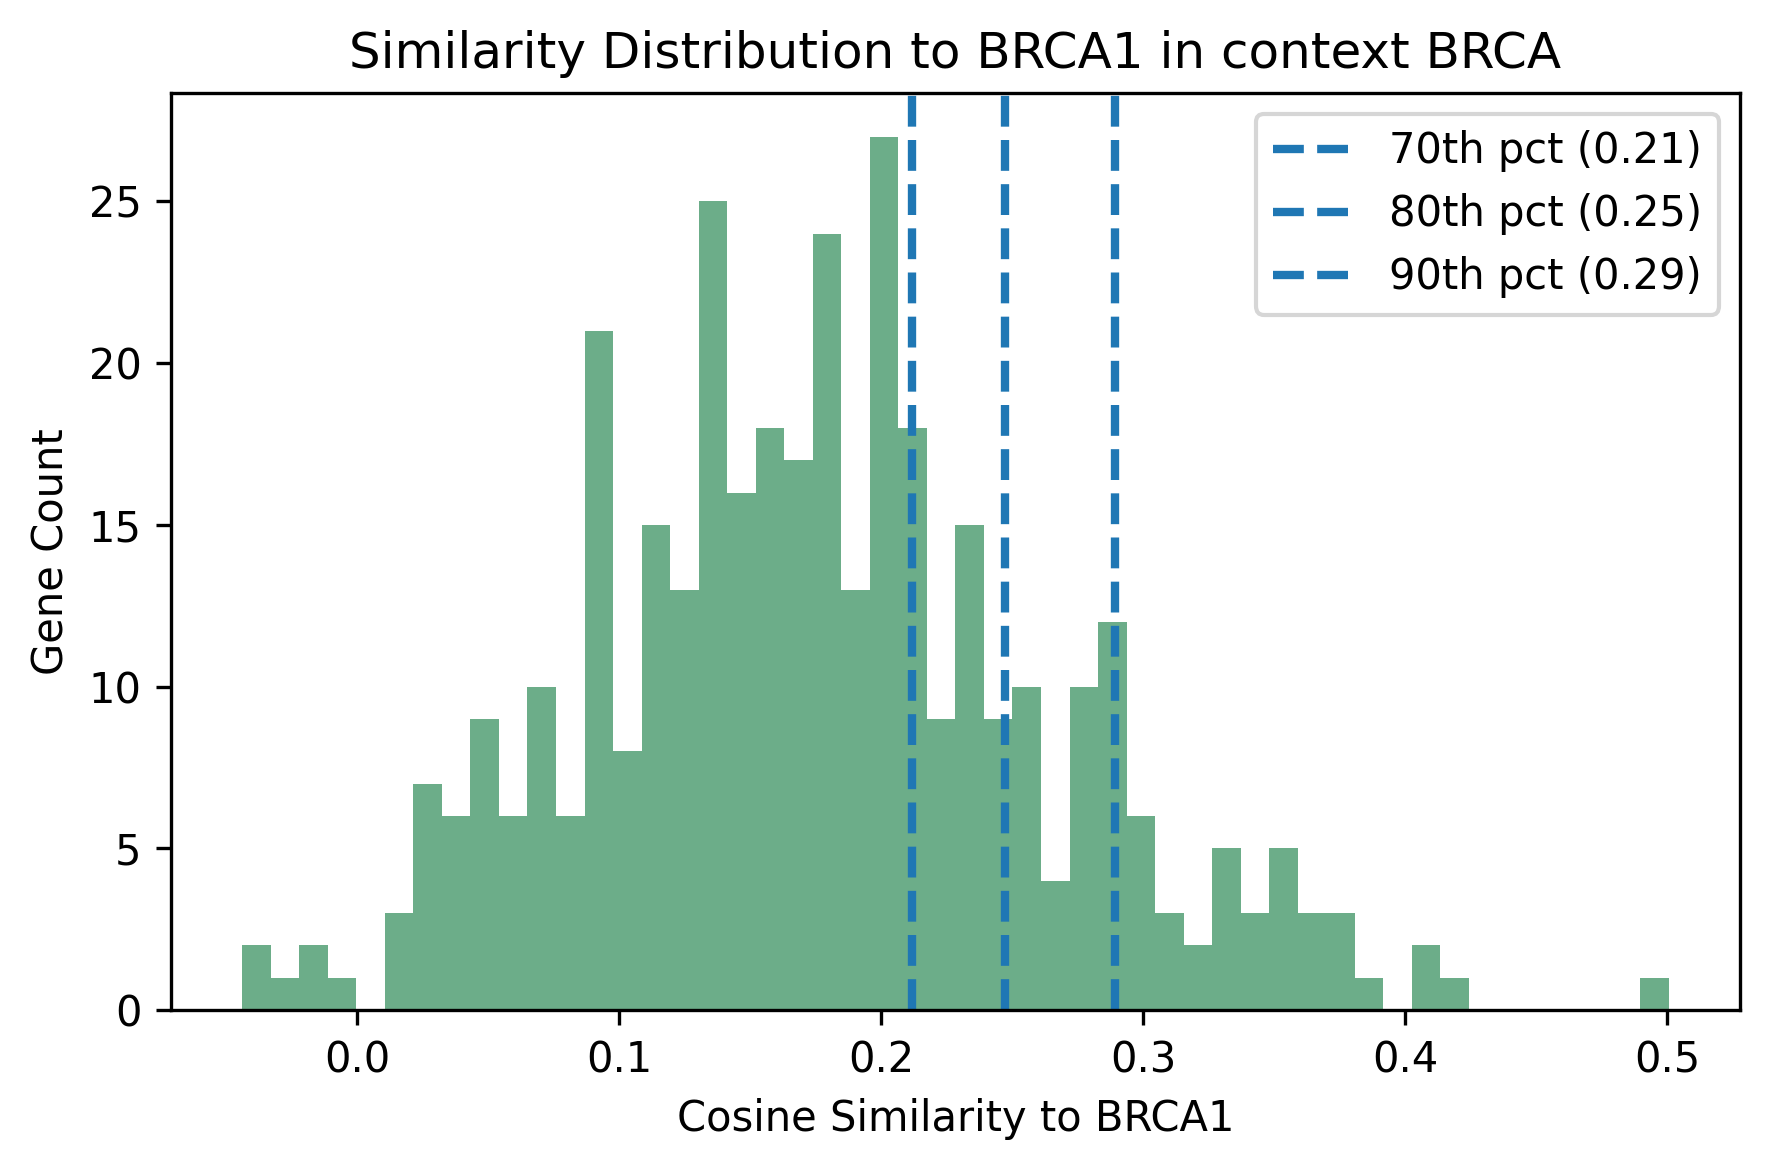

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import numpy as np
import matplotlib.pyplot as plt
import re
import os

def get_mean_embedding_df(df):
    print("Averaging embeddings for each gene.")
    gene_group = df.groupby('gene')['embedding'].apply(lambda x: np.stack(x.values).mean(axis=0))
    df_mean = gene_group.reset_index()
    return df_mean

def plot_similarity_to_target(df, target_gene, cancer="all", bins=50, percentiles=None, mode="sim"):
    """
    df: DataFrame with ['gene','embedding','context']
    target_gene: target gene to compare with
    cancer: "all" or specific cancer name
    mode: "sim" for cosine similarity, "dist" for Euclidean distance
    """
    if cancer == "all":
        df_cancer = get_mean_embedding_df(df)
        title_cancer = "all contexts"
    else:
        df_cancer = df[df['context'] == cancer]
        title_cancer = f"context {cancer}"

    # Extract target gene embedding
    gene_rows = df_cancer[df_cancer['gene'] == target_gene]
    if gene_rows.empty:
        raise ValueError(f"{target_gene} not found in current cancer: {cancer}!")
    target_emb = gene_rows['embedding'].values[0]

    # Compute similarities/distances
    embeddings = np.stack(df_cancer['embedding'].values)
    genes = df_cancer['gene'].tolist()

    plt.figure(figsize=(6, 4), dpi=300)

    if mode == "sim":
        percentiles = [70, 80, 90]
        sims = cosine_similarity(embeddings, [target_emb]).flatten()
        genes, sims = zip(*[(g, s) for g, s in zip(genes, sims) if g != target_gene])  # remove target gene itself

        plt.hist(sims, bins=bins, alpha=0.7, color='seagreen')
        plt.xlabel(f'Cosine Similarity to {target_gene}')
        plt.title(f'Similarity Distribution to {target_gene} in {title_cancer}')
        values = sims

    elif mode == "dist":
        percentiles = [10, 20, 30]
        dists = euclidean_distances(embeddings, [target_emb]).flatten()
        genes, dists = zip(*[(g, d) for g, d in zip(genes, dists) if g != target_gene])  # remove target gene itself

        plt.hist(dists, bins=bins, alpha=0.7, color='steelblue')
        plt.xlabel(f'Euclidean Distance to {target_gene}')
        plt.title(f'Distance Distribution to {target_gene} in {title_cancer}')
        values = dists

    else:
        raise ValueError("Invalid mode. Use 'sim' or 'dist'.")

    plt.ylabel('Gene Count')

    # Draw percentile lines
    if percentiles:
        for pct in percentiles:
            threshold = np.percentile(values, pct)
            plt.axvline(
                threshold,
                linestyle="dashed",
                linewidth=2,
                label=f"{pct}th pct ({threshold:.2f})"
            )
        plt.legend()

    plt.tight_layout()

    # --- Save SVG with descriptive filename ---
    fname = f"Similarity Distribution to {target_gene} in {title_cancer}.svg"
    plt.savefig(fname, format="svg", bbox_inches="tight")
    print(f"Saved figure as: {os.path.abspath(fname)}")

    plt.show()

    return df_cancer, np.array(values), list(genes)



target_gene = geneA   ############
# percentiles = [70, 80, 90]
# percentiles = [10, 20, 30]
df_cancer, sims_or_dists_to_A, gene_list = plot_similarity_to_target(avg_df, target_gene, cancer=cancer, mode="sim") # cancer = "all"





In [13]:
similarity_percentile = 80 # 80
sims_to_A = sims_or_dists_to_A  # Use the similarity scores directly
threshold = np.percentile(sims_to_A, similarity_percentile)

# Get indices where similarity >= threshold
indices = np.where(sims_to_A >= threshold)[0]

# Sort these indices by similarity, descending
sorted_indices = indices[np.argsort(sims_to_A[indices])[::-1]]

single_neighbors = [gene_list[idx] for idx in sorted_indices]

# Print sorted list
print(f"similar genes to {target_gene} in {cancer}")
print(f"Percentile: {similarity_percentile}%, Threshold: {threshold:.4f}, # Genes:{len(sorted_indices)}")
for i, idx in enumerate(sorted_indices[:18]):
    print(f"{i+1:2d}. {gene_list[idx]:10s}  Similarity: {sims_to_A[idx]:.4f}")


similar genes to BRCA1 in BRCA
Percentile: 80%, Threshold: 0.2473, # Genes:75
 1. ST6GAL1     Similarity: 0.5006
 2. BRCA2       Similarity: 0.4205
 3. NOTCH2      Similarity: 0.4087
 4. TRAF4       Similarity: 0.4055
 5. NCEH1       Similarity: 0.3843
 6. FANCA       Similarity: 0.3789
 7. AURKB       Similarity: 0.3772
 8. STK3        Similarity: 0.3735
 9. ECE2        Similarity: 0.3696
10. AK2         Similarity: 0.3643
11. HERC3       Similarity: 0.3618
12. PTPN13      Similarity: 0.3589
13. EXO1        Similarity: 0.3577
14. CDC42BPB    Similarity: 0.3527
15. POLD1       Similarity: 0.3520
16. BRIP1       Similarity: 0.3516
17. MRPL47      Similarity: 0.3424
18. RAD51       Similarity: 0.3376


#### for gene pair

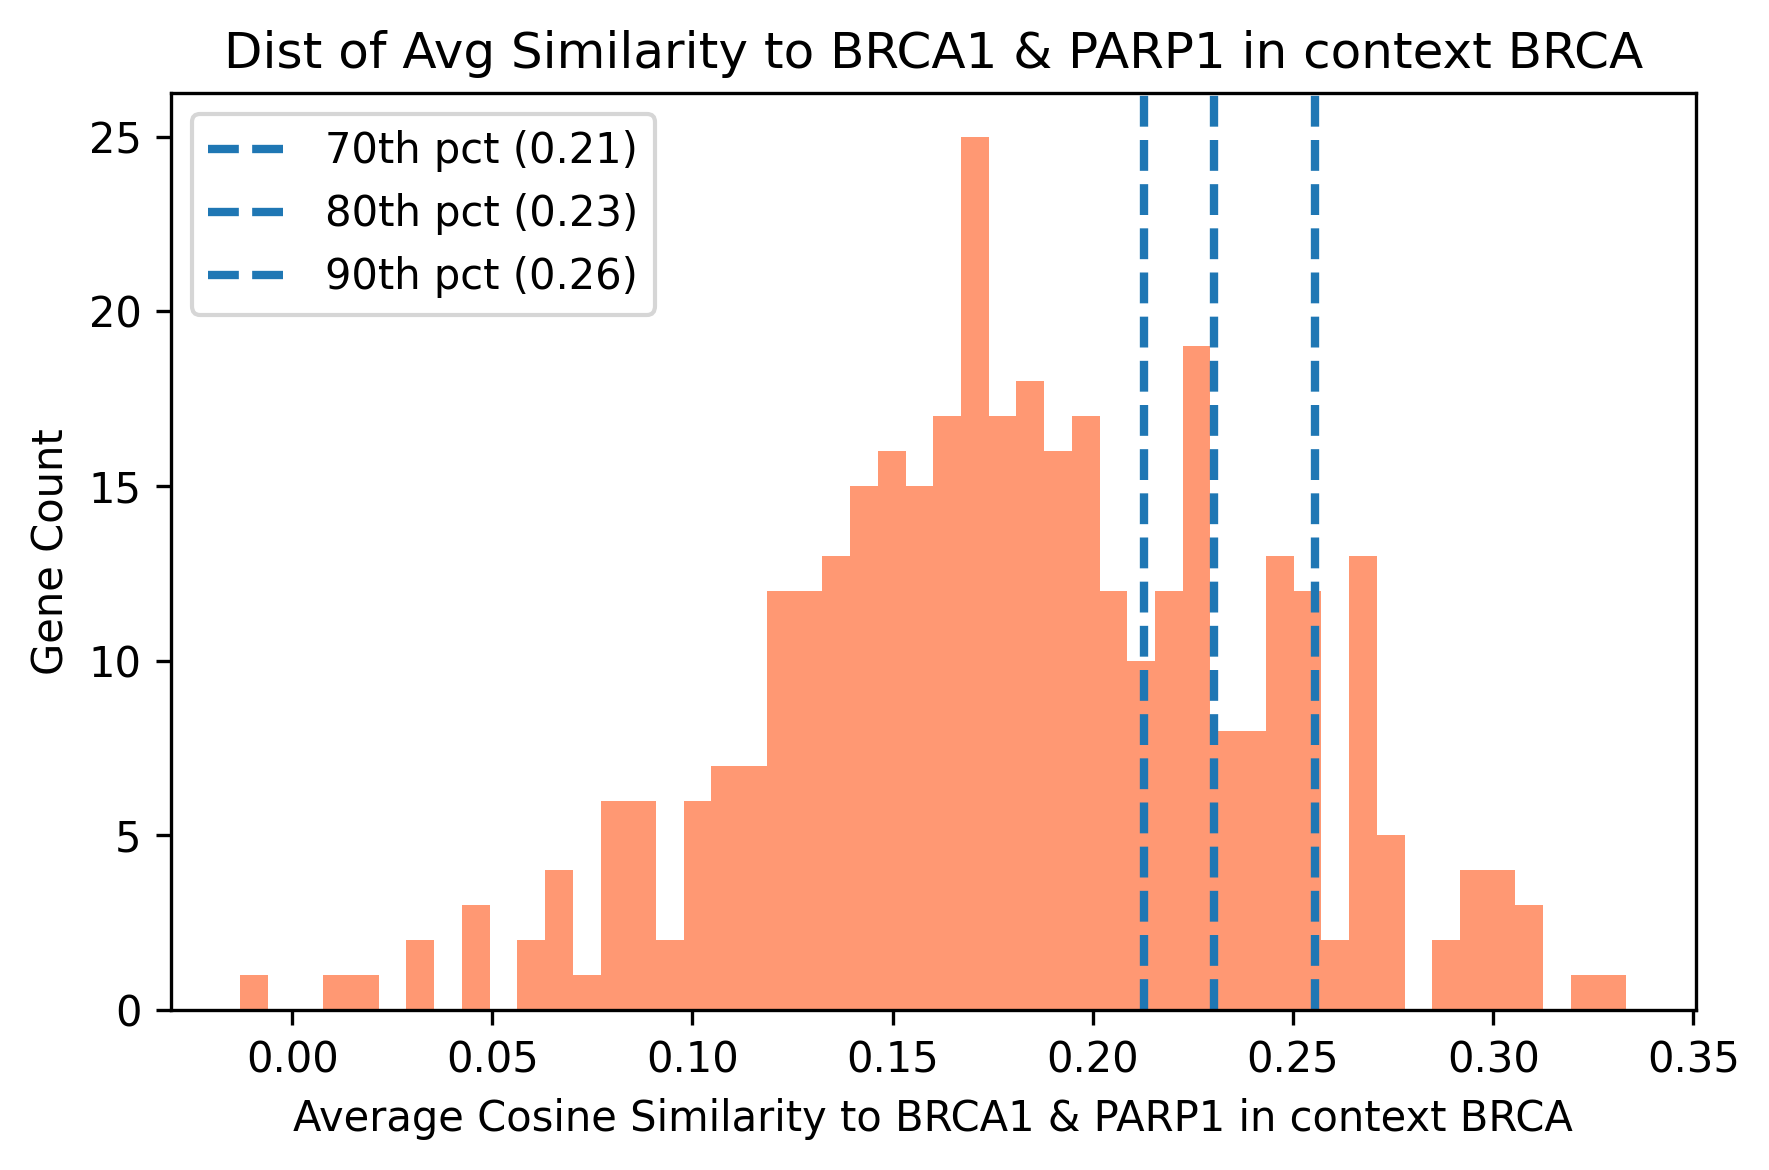

In [15]:
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import numpy as np
import matplotlib.pyplot as plt

def plot_avg_similarity_hist(
    df, geneA, geneB, cancer="all", bins=50, percentiles=None, mode="sim"
):
    if cancer == "all":
        df_cancer = get_mean_embedding_df(df)
        title_cancer = "all contexts"
    else:
        df_cancer = df[df['context'] == cancer]
        title_cancer = f"context {cancer}"
        
    gene_list = df_cancer['gene'].tolist()
    embeddings = np.stack(df_cancer['embedding'].values)

    if geneA not in gene_list or geneB not in gene_list:
        raise ValueError(f"{geneA} or {geneB} not found in gene list for {title_cancer}!")

    idxA = gene_list.index(geneA)
    idxB = gene_list.index(geneB)
    embA = embeddings[idxA]
    embB = embeddings[idxB]

    avg_scores = []
    scoresA = []
    scoresB = []
    other_genes = []

    for i, gene in enumerate(gene_list):
        if gene in (geneA, geneB):
            continue

        if mode == "sim":
            percentiles = [70, 80, 90]
            simA = cosine_similarity([embeddings[i]], [embA])[0][0]
            simB = cosine_similarity([embeddings[i]], [embB])[0][0]
            avg = (simA + simB) / 2

        elif mode == "dist":
            percentiles=[10, 20, 30]
            distA = euclidean_distances([embeddings[i]], [embA])[0][0]
            distB = euclidean_distances([embeddings[i]], [embB])[0][0]
            avg = (distA + distB) / 2
        else:
            raise ValueError("Invalid mode. Use 'sim' or 'dist'.")

        avg_scores.append(avg)
        scoresA.append(simA if mode == "sim" else distA)
        scoresB.append(simB if mode == "sim" else distB)
        other_genes.append(gene)

    avg_scores = np.array(avg_scores)
    scoresA = np.array(scoresA)
    scoresB = np.array(scoresB)

    plt.figure(figsize=(6, 4), dpi=300)
    plt.hist(avg_scores, bins=bins, color="coral", alpha=0.8)

    xlabel = f"Average {'Cosine Similarity' if mode == 'sim' else 'Euclidean Distance'} to {geneA} & {geneB}"
    plt.xlabel(xlabel + f" in {title_cancer}")
    plt.ylabel("Gene Count")
    plt.title(f"Dist of Avg {'Similarity' if mode == 'sim' else 'Distance'} to {geneA} & {geneB} in {title_cancer}")

    if percentiles is not None:
        for pct in percentiles:
            threshold = np.percentile(avg_scores, pct)
            plt.axvline(
                threshold,
                linestyle="dashed",
                linewidth=2,
                label=f"{pct}th pct ({threshold:.2f})"
            )
        plt.legend()
    
    plt.tight_layout()
    plt.savefig(xlabel + f" in {title_cancer}.svg", format="svg", bbox_inches="tight")
    plt.show()

    return avg_scores, scoresA, scoresB, other_genes


# Example usage:
avg_scores, scoresA, scoresB, neighbor_genes = plot_avg_similarity_hist(avg_df, geneA, geneB, cancer, mode="sim")

# avg_scores, scoresA, scoresB, neighbor_genes = plot_avg_similarity_hist(avg_df, geneA, geneB, cancer, percentiles=[10, 20, 30], mode="dist")


In [16]:
similarity_percentile = 80 # 80
threshold = np.percentile(avg_scores, similarity_percentile)
# Zip and filter
filtered = [(g, s_avg, sA, sB) for g, s_avg, sA, sB in zip(neighbor_genes, avg_scores, scoresA, scoresB) if s_avg >= threshold]
filtered_sorted = sorted(filtered, key=lambda x: x[1], reverse=True)

print(f"Percentile: {similarity_percentile}%, Threshold: {threshold:.4f}, # Genes:{len(filtered_sorted)}")
print(f"{'Rank':<5} {'Gene':<10} {'AvgSim':>8} {'SimA':>8} {'SimB':>8}")
for i, (gene, sim_avg, simA, simB) in enumerate(filtered_sorted[:18]):
    print(f"{i+1:<5} {gene:<10} {sim_avg:8.4f} {simA:8.4f} {simB:8.4f}")
    
top_neighbors = [gene for gene, sim_avg, simA, simB in filtered_sorted]

Percentile: 80%, Threshold: 0.2302, # Genes:75
Rank  Gene         AvgSim     SimA     SimB
1     POLD1        0.3333   0.3520   0.3145
2     MERTK        0.3236   0.2262   0.4210
3     POLH         0.3094   0.2844   0.3343
4     RECQL4       0.3066   0.3109   0.3022
5     CTSZ         0.3063   0.2861   0.3264
6     ECE2         0.3030   0.3696   0.2365
7     AURKB        0.3017   0.3772   0.2261
8     MAP3K1       0.3008   0.2868   0.3148
9     CDH1         0.2993   0.1181   0.4805
10    TTC14        0.2986   0.0627   0.5345
11    AK2          0.2978   0.3643   0.2314
12    DSCC1        0.2976   0.3352   0.2600
13    ST6GAL1      0.2942   0.5006   0.0877
14    MAP2K6       0.2857   0.2391   0.3323
15    VPS28        0.2855   0.2869   0.2842
16    NCEH1        0.2752   0.3843   0.1661
17    BRCA2        0.2752   0.4205   0.1299
18    SERPINH1     0.2747   0.2053   0.3440


### pathway enrichment analysis

In [18]:
import pandas as pd
import gseapy as gp

df_database = pd.DataFrame([
    ['GO_Biological_Process_2021', 6036],
    ['GO_Molecular_Function_2021', 1274],
    ['Reactome_2022', 1818],
    ['KEGG_2021_Human', 332] ####
], columns=['dataset', 'term'])

In [20]:
geneA = "BRCA1"; geneB = "PARP1"; cancer = "BRCA"
# geneA = "IDH1"; geneB = "PRKDC"; cancer = "all"
## KRAS and TBK1 in LUAD
# geneA = "KRAS" ; geneB = "TBK1"; cancer = "LUAD"


# cancer = "all"
# ['KIRC', 'COAD', 'LAML', 'OV', 'BRCA', 'CESC', 'SKCM', 'LUAD', 'Glioma']
topk_sim = 100

print(geneA, geneB, cancer)

BRCA1 PARP1 BRCA


In [21]:
outdir=f'./enrich_results/enr_res_dis_{geneA}_{geneB}_in_{cancer}' ## gene pair

Bonferroni-corrected p-value threshold: 2.7503e-05


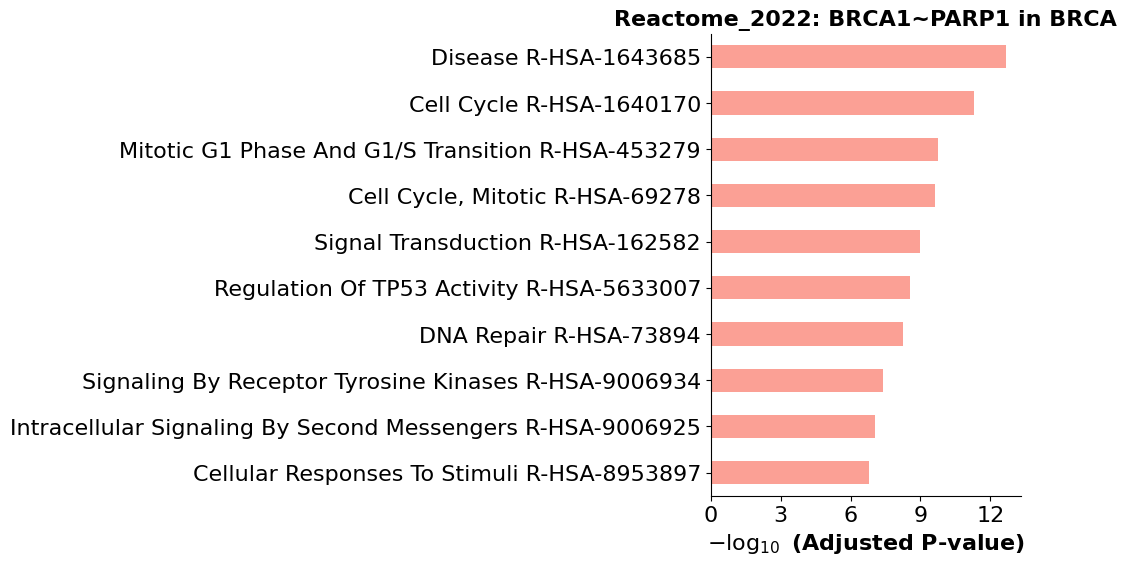

In [22]:
databases = ['Reactome_2022']
# databases = ["KEGG_2021_Human"]
# databases = ['GO_Biological_Process_2021', 'GO_Molecular_Function_2021']
# databases = ['GO_Biological_Process_2021']
m = df_database[df_database['dataset'].isin(databases)]['term'].sum()
p_thresh = 0.05 / m  # Bonferroni correction
print(f"Bonferroni-corrected p-value threshold: {p_thresh:.4e}")

enr_result = gp.enrichr(
    gene_list=gene_list,
    gene_sets=databases,
    organism='Human',
    outdir=outdir,
    cutoff=0.5,  ## 0.5
)

result_df = enr_result.results
filtered_df = result_df[result_df['P-value'] < p_thresh]
# filtered_df = result_df[result_df['P-value'] < 0.05]

# print(filtered_df[['Term', 'P-value', 'Adjusted P-value', 'Genes']])

gp.barplot(result_df, title=f'{databases[0]}: {geneA}~{geneB} in {cancer}', ofname=None, dpi=300)
plt.title(f'{databases[0]}: {geneA}~{geneB} in {cancer}', fontsize=16, weight='bold') 
plt.show()



## Function & Embeddings

In [30]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm
import math

def build_gene_adata(gene, emb, context, cancer_type):
    """
    Create AnnData object for gene embeddings from a specific cancer context.
    """
    gene = np.array(gene)
    emb = np.array(emb)
    context = np.array(context)

    mask = context == cancer_type
    emb_cancer = emb[mask]
    gene_cancer = gene[mask]

    adata = ad.AnnData(X=emb_cancer)
    adata.obs['gene'] = gene_cancer
    adata.obs['context'] = cancer_type

    return adata

def run_louvain_clustering(adata, resolution=2.0):
    """
    Run Louvain clustering on the gene-level embeddings.
    """
    sc.pp.neighbors(adata, n_neighbors=15, use_rep="X")
    # sc.pp.neighbors(adata, use_rep='X', metric='cosine')
    # sc.tl.louvain(adata, resolution=resolution, key_added='gene_cluster')
    sc.tl.leiden(adata, resolution=resolution, key_added='gene_cluster')
    return adata

def get_metagenes(adata, min_genes=5):
    """
    Retrieve gene clusters with >= min_genes genes.
    """
    clusters = adata.obs['gene_cluster'].unique()
    metagenes = {}
    for cluster in clusters:
        genes = adata.obs.loc[adata.obs['gene_cluster'] == cluster, 'gene'].tolist()
        if len(genes) >= min_genes:
            metagenes[str(cluster)] = genes
    return metagenes


In [31]:
cancer_name = "BRCA"
adata = build_gene_adata(gene, emb, context, cancer_name)
adata = run_louvain_clustering(adata, resolution=1.0)
metagenes = get_metagenes(adata)


In [32]:
# Print all metagenes with their number of genes
for cluster_id, genes in metagenes.items():
    print(f"Metagene {cluster_id}: {len(genes)} genes {genes}")


Metagene 3: 53 genes ['AADAT', 'ACOT11', 'AHCY', 'ANAPC5', 'ARHGEF12', 'ATP11A', 'ATP1B3', 'AXL', 'BRD9', 'CALD1', 'CANX', 'CARM1', 'CCNL1', 'CKS2', 'DAP3', 'DGKQ', 'DGKZ', 'DMKN', 'E2F5', 'ERBB3', 'EZH2', 'GNB4', 'ITPR2', 'KIT', 'LIMK2', 'MAP2K3', 'MAP3K2', 'NEIL2', 'NME1', 'NME7', 'PAPSS2', 'PDLIM5', 'PNKP', 'PTX3', 'RAC1', 'RPL22', 'RTP4', 'SDC2', 'SERPINH1', 'SLC39A4', 'SPHK1', 'SQLE', 'STK17A', 'STK32C', 'STK38L', 'TBRG1', 'THNSL1', 'TLN1', 'TMEM67', 'TP53RK', 'TTK', 'ZC3HAV1', 'ZFP36']
Metagene 1: 68 genes ['AAK1', 'ABCC4', 'ACTA2', 'ADAM9', 'ADH5', 'AK2', 'AK3', 'ASAP1', 'ATP11B', 'AZIN1', 'BIRC3', 'CAMKK2', 'CANT1', 'CDK2', 'CDK4', 'CDK6', 'CIT', 'CNTLN', 'COPE', 'CSNK1A1', 'DDX49', 'DNAJB6', 'DSCC1', 'ECT2', 'FH', 'GCNT2', 'GEM', 'GNAS', 'GNE', 'H2AFZ', 'HCK', 'HDAC1', 'HERPUD1', 'HIST1H1D', 'IL6ST', 'INSR', 'KDELR2', 'MAP3K8', 'MAPK12', 'MAPK9', 'MCCC1', 'MTHFD2', 'MTSS1', 'NAAA', 'NEK2', 'NIPAL2', 'PAICS', 'PHKG1', 'PIK3CB', 'PKMYT1', 'PLK1', 'PNMA1', 'PRKAA1', 'PRPF4B', 'PT

In [33]:
def plot_similarity_networks_subplots(metagenes, emb_dict, cancer_name, threshold=0.4, max_genes=100):
    """
    Plot cosine similarity networks for each metagene as subplots.
    """
    n_clusters = len(metagenes)
    ncols = 2
    nrows = math.ceil(n_clusters / ncols)

    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10 * ncols, 8 * nrows))
    axs = axs.flatten()

    for i, (cluster_id, genes) in enumerate(metagenes.items()):
        ax = axs[i]

        # Limit number of genes for readability
        genes = [g for g in genes if g in emb_dict]
        if len(genes) > max_genes:
            genes = genes[:max_genes]

        vectors = [emb_dict[g] for g in genes]
        sim_matrix = cosine_similarity(vectors)
        ##### why re-compute pairwise cosine similarity within each cluster for plotting
        # Louvain/Leiden uses a graph built from k-nearest neighbors on 
        # embeddings to assign cluster labels. only outputs cluster assignments, 
        # not meaningful edge weights between individual nodes (genes).
        names = genes

        edges = []
        for m in range(len(names)):
            for n in range(m + 1, len(names)):
                sim = sim_matrix[m][n]
                if sim > threshold:
                    edges.append((names[m], names[n], round(sim, 2)))

        G = nx.Graph()
        G.add_weighted_edges_from(edges)

        pos = nx.spring_layout(G, k=0.4, iterations=15, seed=3)
        edge_widths = [d['weight'] * 10 for u, v, d in G.edges(data=True)]

        nx.draw(G, pos, ax=ax,
                with_labels=True,
                node_size=500,
                edge_color='lightblue',
                width=edge_widths,
                font_size=8)
        edge_labels = nx.get_edge_attributes(G, "weight")
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6, ax=ax)

        ax.set_title(f"Cancer: {cancer_name} - Cluster {cluster_id} ({len(genes)} genes)")
        ax.axis("off")

    # Hide unused subplots
    for j in range(i + 1, len(axs)):
        axs[j].axis('off')

    plt.tight_layout()
    plt.show()


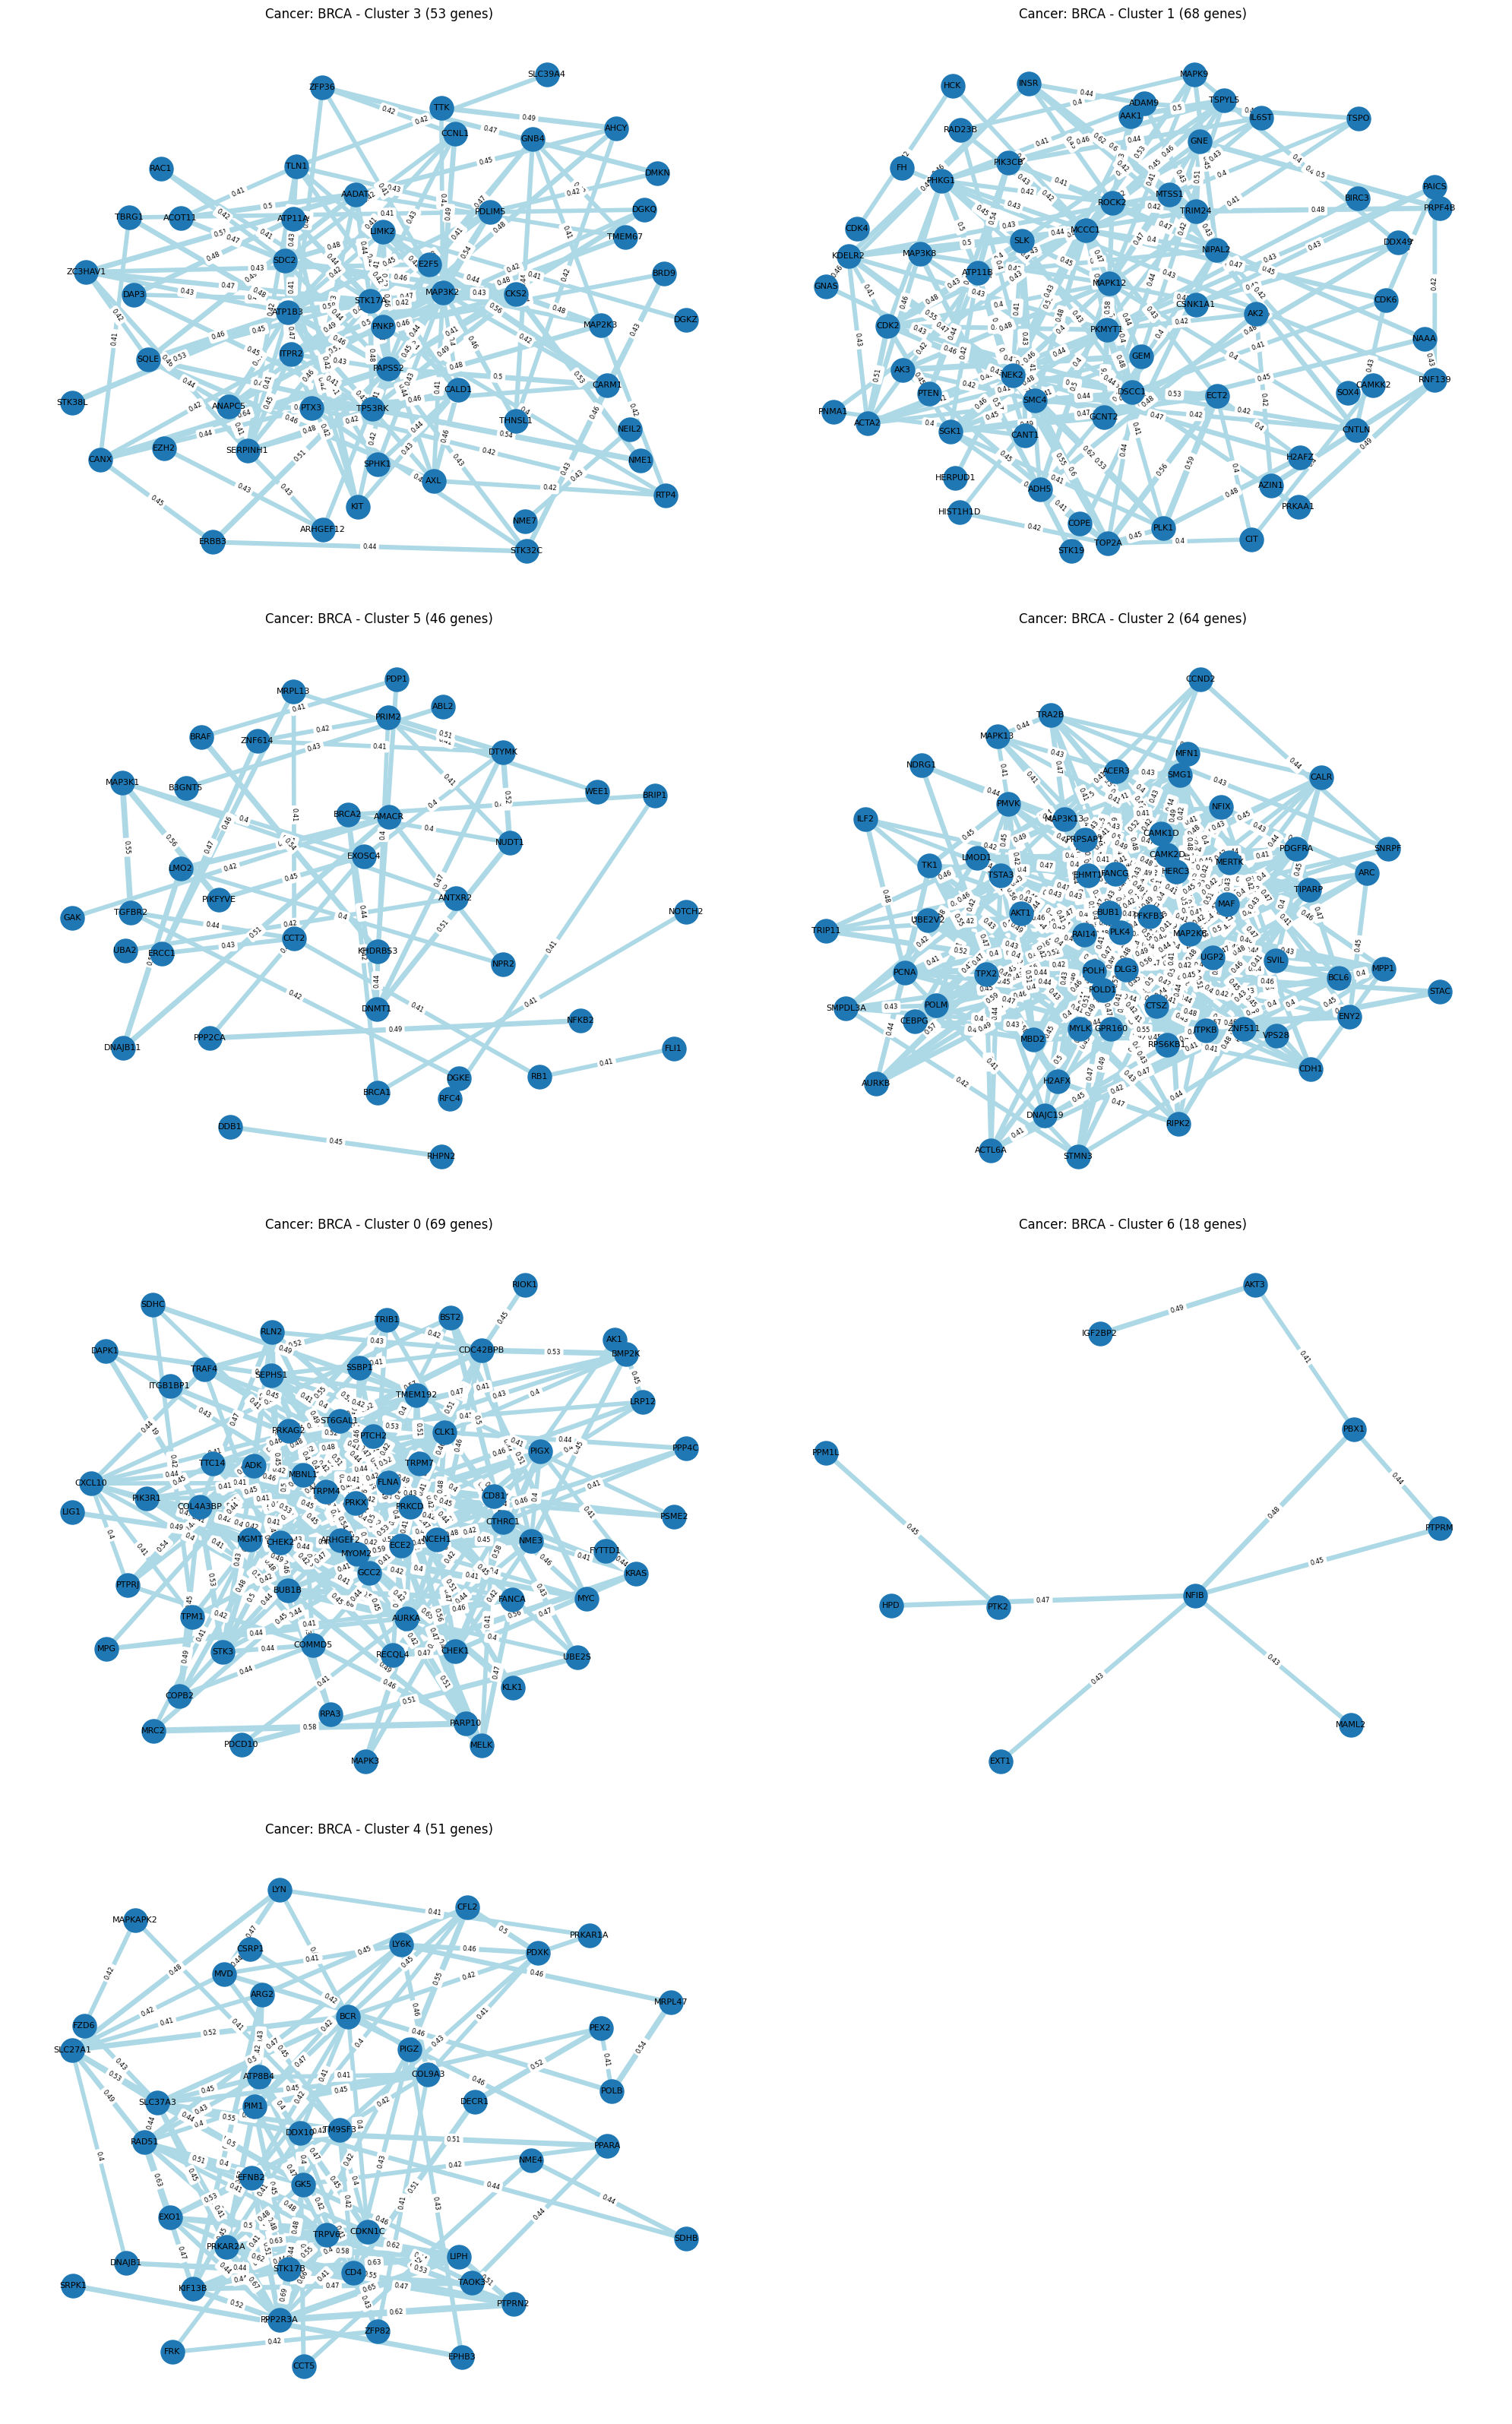

In [34]:
# Create embedding dictionary
emb_dict = {g: vec for g, vec in zip(adata.obs['gene'], adata.X)}

# Plot networks
plot_similarity_networks_subplots(metagenes, emb_dict, cancer_name, threshold=0.4)


In [35]:
import itertools
import pandas as pd
from collections import defaultdict

def find_shared_goterms(gene1, gene2, anno_mapped):
    go_terms_gene1 = set(anno_mapped.get(gene1, []))
    go_terms_gene2 = set(anno_mapped.get(gene2, []))
    return go_terms_gene1.intersection(go_terms_gene2)

def analyze_go_similarity_in_metagenes(metagenes, anno_mapped, min_shared_threshold=3):
    """
    For each gene cluster, compute number of shared GO terms per gene pair,
    and count how many exceed a threshold (e.g., ≥3 shared GO terms).
    """
    all_results = []
    summary = []

    for cluster_id, genes in metagenes.items():
        gene_pairs = list(itertools.combinations(genes, 2))
        cluster_data = []

        for g1, g2 in gene_pairs:
            shared = find_shared_goterms(g1, g2, anno_mapped)
            cluster_data.append({
                'cluster': cluster_id,
                'gene1': g1,
                'gene2': g2,
                'n_shared': len(shared),
                'shared_terms': list(shared)
            })

        df_cluster = pd.DataFrame(cluster_data)
        high_shared_count = (df_cluster['n_shared'] >= min_shared_threshold).sum()
        avg_shared = df_cluster['n_shared'].mean()

        summary.append({
            'cluster': cluster_id,
            'num_genes': len(genes),
            'num_pairs': len(gene_pairs),
            'high_shared_pairs': high_shared_count,
            'avg_shared_terms': avg_shared
        })

        all_results.append(df_cluster)

    df_all_pairs = pd.concat(all_results, ignore_index=True)
    df_summary = pd.DataFrame(summary)

    return df_all_pairs, df_summary


def compute_background_shared_go(metagenes, anno_mapped, num_samples=5000):
    """
    Sample random gene pairs from the full gene set and compute shared GO terms.
    """
    gene_pool = set()
    for gene_list in metagenes.values():
        gene_pool.update(gene_list)
    gene_pool = list(gene_pool)
    gene_pool = [g for g in gene_pool if g in anno_mapped]
    print(f"Total unique genes in pool: {len(gene_pool)}")
    sampled_pairs = random.sample(list(itertools.combinations(gene_pool, 2)), num_samples)

    results = []
    for g1, g2 in sampled_pairs:
        shared = find_shared_goterms(g1, g2, anno_mapped)
        results.append({
            'gene1': g1,
            'gene2': g2,
            'n_shared': len(shared),
            'shared_terms': list(shared)
        })

    df_background = pd.DataFrame(results)
    return df_background


In [36]:
from goatools.obo_parser import GODag
from goatools.associations import read_gaf

go_dag = GODag("/home/jienihu/sc/SLformer/data/GO/go-basic.obo")
annotations = read_gaf("/home/jienihu/sc/SLformer/data/GO/goa_human.gaf", go_dag=go_dag)

/home/jienihu/sc/SLformer/data/GO/go-basic.obo: fmt(1.2) rel(2024-06-17) 45,494 Terms
HMS:0:00:18.615815 707,170 annotations READ: /home/jienihu/sc/SLformer/data/GO/goa_human.gaf 
36129 IDs in loaded association branch, BP


In [37]:
id_mapping = pd.read_csv("/home/jienihu/sc/SLformer/data/GO/idmapping_2024_11_09.tsv", sep='\t')
id_mapping = dict(zip(id_mapping['From'], id_mapping['To']))
anno_mapped = {}
for k, v in annotations.items():
    if k in id_mapping:
        anno_mapped[id_mapping[k]] = v

In [38]:
df_background = compute_background_shared_go(metagenes, anno_mapped, num_samples=20000)

print(f"Background avg shared GO terms: {df_background['n_shared'].mean():.3f}")


Total unique genes in pool: 357
Background avg shared GO terms: 0.209


In [39]:
# anno_mapped = {gene_symbol: [GO_IDs]} 
df_all, df_summary = analyze_go_similarity_in_metagenes(metagenes, anno_mapped, min_shared_threshold=3)
df_background = compute_background_shared_go(metagenes, anno_mapped, num_samples=10000)

print("Summary of GO term sharing per cluster:")
df_summary_sorted = df_summary.sort_values(by='avg_shared_terms', ascending=False)
print(df_summary_sorted)

print(f"Background avg shared GO terms: {df_background['n_shared'].mean():.3f}")

# # Save detailed results for analysis or plotting
# df_all.to_csv("go_term_pairwise_details.csv", index=False)
# df_summary.to_csv("go_term_cluster_summary.csv", index=False)


Total unique genes in pool: 357
Summary of GO term sharing per cluster:
  cluster  num_genes  num_pairs  high_shared_pairs  avg_shared_terms
5       6         18        153                  3          0.267974
1       1         68       2278                 47          0.263389
2       5         46       1035                 21          0.235749
3       2         64       2016                 29          0.200893
4       0         69       2346                 38          0.183717
6       4         51       1275                 19          0.178039
0       3         53       1378                 15          0.144412
Background avg shared GO terms: 0.211


### Pathway enrichment

In [16]:
import pandas as pd
import gseapy as gp

df_database = pd.DataFrame([
    ['GO_Biological_Process_2021', 6036],
    ['GO_Molecular_Function_2021', 1274],
    ['Reactome_2022', 1818],
    ['KEGG_2021_Human', 332] ####
], columns=['dataset', 'term'])

In [17]:
databases = ['Reactome_2022']
# databases = ["KEGG_2021_Human"]
# databases = ['GO_Biological_Process_2021', 'GO_Molecular_Function_2021']
m = df_database[df_database['dataset'].isin(databases)]['term'].sum()
p_thresh = 0.05 / m  # Bonferroni correction
p_thresh

2.7502750275027505e-05

In [ ]:
selected_cluster = '1'  
gene_list = metagenes[selected_cluster]
print(len(gene_list), gene_list)

In [289]:
enr_result = gp.enrichr(
    gene_list=gene_list,
    gene_sets=databases,
    organism='Human',
    outdir=f'./enr_results_cosine_{cancer_name}_cluster{selected_cluster}',
    cutoff=0.5,   # Adjust as needed
)

result_df = enr_result.results
filtered_df = result_df[result_df['P-value'] < p_thresh]
# filtered_df = result_df[result_df['P-value'] < 0.05]

print(filtered_df[['Term', 'P-value', 'Adjusted P-value', 'Genes']])


/home/tinglu/anaconda3/envs/lifespan/lib/python3.9/site-packages/gseapy/enrichr.py:427: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  self.results = self.results.append(res, ignore_index=True)


                                                Term   P-value  \
0                             DNA Repair R-HSA-73894  0.000002   
1                    Cell Cycle, Mitotic R-HSA-69278  0.000003   
2                           Cell Cycle R-HSA-1640170  0.000005   
3  Resolution Of Abasic Sites (AP Sites) R-HSA-73933  0.000012   
4  Global Genome Nucleotide Excision Repair (GG-N...  0.000013   
5       DNA Double-Strand Break Repair R-HSA-5693532  0.000019   

   Adjusted P-value                                              Genes  
0          0.000741  NEIL2;PCNA;PARP1;POLM;POLD1;ACTL6A;UBE2V2;FANC...  
1          0.000741  RB1;PLK4;TPX2;PCNA;CCND2;NME7;POLD1;AKT1;TK1;B...  
2          0.000741  RB1;PLK4;TPX2;PCNA;CCND2;NME7;POLD1;UBE2V2;AKT...  
3          0.001266                             PCNA;NEIL2;PARP1;POLD1  
4          0.001266                     PCNA;PARP1;POLD1;ACTL6A;UBE2V2  
5          0.001506                  PCNA;PARP1;POLM;POLD1;UBE2V2;POLH  
